Name: Sat Naing Tun,  ID:st125333

In [1]:
import torch
import torchvision
from torchvision import datasets, models, transforms
import torch.nn as nn
import torch.optim as optim
import time
import os
import copy
import torch.nn.functional as F
from pathlib import Path
import math, time, copy, random
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [2]:
colab = False
if colab:
    from google.colab import drive
    drive.mount('/content/gdrive')

    # Your root path in gdrive
    root_path = 'gdrive/My Drive/'
else:
    root_path = './'

In [3]:
SEED = 32
random.seed(SEED); torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [21]:
EPOCHS = 20
LEARNING_RATE = 0.01
AUX_WEIGHT = 0.3

In [4]:

transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.4914,0.4822,0.4465), (0.247,0.243,0.261))
])
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914,0.4822,0.4465), (0.247,0.243,0.261))
])
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
testset  = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)
testloader  = torch.utils.data.DataLoader(testset, batch_size=128, shuffle=False, num_workers=2)

100%|██████████| 170M/170M [00:05<00:00, 31.8MB/s]


In [5]:

def train_one_epoch(model, loader, criterion, optimizer, device, aux_weight=0.0):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        outputs = model(x)
        if isinstance(outputs, tuple):
            main_out = outputs[0]
            loss = criterion(main_out, y)
            for aux_out in outputs[1:]:
                if aux_out is not None and aux_weight > 0.0:
                    loss += aux_weight * criterion(aux_out, y)
            preds = main_out.argmax(1)
        else:
            loss = criterion(outputs, y)
            preds = outputs.argmax(1)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
        correct += (preds == y).sum().item()
        total += y.size(0)
    return total_loss / total, correct / total

In [6]:
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    import torch
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            if isinstance(outputs, tuple):
                outputs = outputs[0]
            loss = criterion(outputs, y)
            total_loss += loss.item() * x.size(0)
            correct += (outputs.argmax(1) == y).sum().item()
            total += y.size(0)
    return total_loss / total, correct / total

In [7]:
def train_model(model, trainloader, testloader, epochs, lr, aux_weight=0.0):
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=5e-4)

    train_losses, val_losses, train_accs, val_accs = [], [], [], []

    for epoch in range(epochs):
        tr_loss, tr_acc = train_one_epoch(model, trainloader, criterion, optimizer, device, aux_weight)
        val_loss, val_acc = evaluate(model, testloader, criterion, device)

        train_losses.append(tr_loss)
        val_losses.append(val_loss)
        train_accs.append(tr_acc)
        val_accs.append(val_acc)

        print(f"Epoch {epoch+1}/{epochs} | TrainAcc={tr_acc:.3f} | ValAcc={val_acc:.3f} | TrainLoss={tr_loss:.3f}| ValidationLoss={val_loss:.3f}")


    return model, train_losses, val_losses, train_accs, val_accs

In [8]:
def plot_curves(train_acc, val_acc, train_loss, val_loss, title):
    import matplotlib.pyplot as plt
    plt.figure(figsize=(5,4))
    plt.plot(train_loss, label='Train Loss')
    plt.plot(val_loss, label='Val Loss')
    plt.legend(); plt.title(f'{title} Loss'); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.grid(True, alpha=0.3); plt.show()
    plt.figure(figsize=(5,4))
    plt.plot(train_acc, label='Train Acc')
    plt.plot(val_acc, label='Val Acc')
    plt.legend(); plt.title(f'{title} Accuracy'); plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.grid(True, alpha=0.3); plt.show()


In [9]:
def test_accuracy(model, loader, device=device):
    model.eval(); correct, total = 0, 0
    import torch
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            if isinstance(outputs, tuple):
                outputs = outputs[0]
            preds = outputs.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)
    acc = correct / total
    print(f"Test Accuracy: {acc*100:.2f}%")
    return acc


In [10]:
import torch.nn as nn

class AlexNetModule(nn.Module):

    def __init__(self, num_classes: int = 10) -> None:
        super().__init__()
        self.num_classes = num_classes
        self.features = nn.Sequential(
          nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1),
          nn.ReLU(inplace=True),
          nn.MaxPool2d(kernel_size=2, stride=2),

          nn.Conv2d(64, 192, kernel_size=3, padding=1),
          nn.ReLU(inplace=True),
          nn.MaxPool2d(kernel_size=2, stride=2),

          nn.Conv2d(192, 384, kernel_size=3, padding=1),
          nn.ReLU(inplace=True),
          nn.Conv2d(384, 256, kernel_size=3, padding=1),
          nn.ReLU(inplace=True),
          nn.Conv2d(256, 256, kernel_size=3, padding=1),
          nn.ReLU(inplace=True),
          nn.MaxPool2d(kernel_size=2, stride=2),
      )
        self.avgpool = nn.AdaptiveAvgPool2d((2, 2))
        self.classifier = nn.Sequential(
          nn.Dropout(),
          nn.Linear(256 * 2 * 2, 4096),
          nn.ReLU(inplace=True),
          nn.Dropout(),
          nn.Linear(4096, 4096),
          nn.ReLU(inplace=True),
          nn.Linear(4096, num_classes),
      )


    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

Epoch 1/20 | TrainAcc=0.142 | ValAcc=0.236 | TrainLoss=2.250| ValidationLoss=2.010
Epoch 2/20 | TrainAcc=0.283 | ValAcc=0.345 | TrainLoss=1.864| ValidationLoss=1.742
Epoch 3/20 | TrainAcc=0.380 | ValAcc=0.449 | TrainLoss=1.621| ValidationLoss=1.448
Epoch 4/20 | TrainAcc=0.457 | ValAcc=0.521 | TrainLoss=1.441| ValidationLoss=1.286
Epoch 5/20 | TrainAcc=0.530 | ValAcc=0.584 | TrainLoss=1.284| ValidationLoss=1.139
Epoch 6/20 | TrainAcc=0.588 | ValAcc=0.638 | TrainLoss=1.139| ValidationLoss=1.021
Epoch 7/20 | TrainAcc=0.627 | ValAcc=0.628 | TrainLoss=1.032| ValidationLoss=1.036
Epoch 8/20 | TrainAcc=0.661 | ValAcc=0.694 | TrainLoss=0.940| ValidationLoss=0.884
Epoch 9/20 | TrainAcc=0.684 | ValAcc=0.700 | TrainLoss=0.879| ValidationLoss=0.841
Epoch 10/20 | TrainAcc=0.710 | ValAcc=0.740 | TrainLoss=0.818| ValidationLoss=0.756
Epoch 11/20 | TrainAcc=0.733 | ValAcc=0.734 | TrainLoss=0.755| ValidationLoss=0.762
Epoch 12/20 | TrainAcc=0.749 | ValAcc=0.758 | TrainLoss=0.718| ValidationLoss=0.691
E

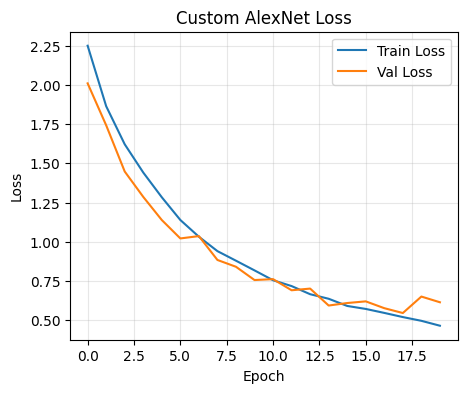

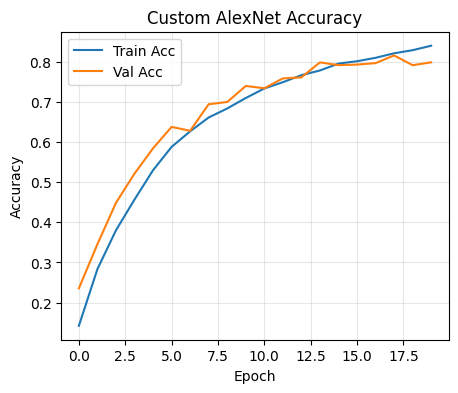

Test Accuracy: 79.85%


In [11]:
alexnet = AlexNetModule(num_classes=10).to(device)
alexnet, trL_a, vaL_a, trA_a, vaA_a = train_model(alexnet, trainloader, testloader, epochs=20, lr=0.01, aux_weight=0.0)
plot_curves(trA_a, vaA_a, trL_a, vaL_a, "Custom AlexNet")
alex_acc = test_accuracy(alexnet, testloader)

In [12]:

class Inception(nn.Module):
    def __init__(self, in_channels, ch1x1, ch3x3red, ch3x3, ch5x5red, ch5x5, pool_proj):
        super().__init__()
        self.branch1 = nn.Sequential(
            nn.Conv2d(in_channels, ch1x1, kernel_size=1),
            nn.BatchNorm2d(ch1x1),
            nn.ReLU(True)
        )
        self.branch2 = nn.Sequential(
            nn.Conv2d(in_channels, ch3x3red, kernel_size=1),
            nn.BatchNorm2d(ch3x3red),
            nn.ReLU(True),
            nn.Conv2d(ch3x3red, ch3x3, kernel_size=3, padding=1),
            nn.BatchNorm2d(ch3x3),
            nn.ReLU(True)
        )
        self.branch3 = nn.Sequential(
            nn.Conv2d(in_channels, ch5x5red, kernel_size=1),
            nn.BatchNorm2d(ch5x5red),
            nn.ReLU(True),
            nn.Conv2d(ch5x5red, ch5x5, kernel_size=5, padding=2),
            nn.BatchNorm2d(ch5x5),
            nn.ReLU(True)
        )
        self.branch4 = nn.Sequential(
            nn.MaxPool2d(kernel_size=3, stride=1, padding=1),
            nn.Conv2d(in_channels, pool_proj, kernel_size=1),
            nn.BatchNorm2d(pool_proj),
            nn.ReLU(True)
        )
    def forward(self, x):
        o1 = self.branch1(x)
        o2 = self.branch2(x)
        o3 = self.branch3(x)
        o4 = self.branch4(x)
        return torch.cat([o1, o2, o3, o4], 1)

In [30]:
class GoogLeNet(nn.Module):
    def __init__(self, num_classes=10, use_aux=True):
        super().__init__()
        self.use_aux = use_aux
        self.pre_layers = nn.Sequential(
            nn.Conv2d(3, 192, kernel_size=3, padding=1),
            nn.BatchNorm2d(192),
            nn.ReLU(True),
        )
        self.a3 = Inception(192, 64, 96, 128, 16, 32, 32)   # -> 256
        self.b3 = Inception(256, 128, 128, 192, 32, 96, 64) # -> 480
        self.maxpool = nn.MaxPool2d(3, stride=2, padding=1)
        self.a4 = Inception(480, 192, 96, 208, 16, 48, 64)  # -> 512
        self.b4 = Inception(512, 160, 112, 224, 24, 64, 64) # -> 512
        self.c4 = Inception(512, 128, 128, 256, 24, 64, 64) # -> 512
        self.d4 = Inception(512, 112, 144, 288, 32, 64, 64) # -> 528
        self.e4 = Inception(528, 256, 160, 320, 32, 128, 128) # -> 832
        self.a5 = Inception(832, 256, 160, 320, 32, 128, 128) # -> 832
        self.b5 = Inception(832, 384, 192, 384, 48, 128, 128)  # -> 1024
        self.avgpool = nn.AvgPool2d(8, stride=1)
        self.linear = nn.Linear(1024, num_classes)
        
        if self.use_aux:
             
              self.aux1_pool = nn.AdaptiveAvgPool2d((4, 4))
              self.aux1_head = nn.Sequential(
                  nn.Conv2d(512, 128, kernel_size=1),
                  nn.ReLU(inplace=True),
                  nn.Flatten(),                     
                  nn.Linear(128 * 4 * 4, 1024),
                  nn.ReLU(inplace=True),
                  nn.Dropout(0.7),
                  nn.Linear(1024, num_classes)
              )

              self.aux2_pool = nn.AdaptiveAvgPool2d((4, 4))
              self.aux2_head = nn.Sequential(
                  nn.Conv2d(528, 128, kernel_size=1),
                  nn.ReLU(inplace=True),
                  nn.Flatten(),                    
                  nn.Linear(128 * 4 * 4, 1024),
                  nn.ReLU(inplace=True),
                  nn.Dropout(0.7),
                  nn.Linear(1024, num_classes)
              )

    def forward(self, x):
        out = self.pre_layers(x)
        out = self.a3(out)
        out = self.b3(out)
        out = self.maxpool(out)

        out = self.a4(out)
        out = self.b4(out)
        out = self.c4(out)

        aux1_out = None
        if self.use_aux and self.training:
            a1 = self.aux1_pool(out)           
            aux1_out = self.aux1_head(a1)

        out = self.d4(out)

        aux2_out = None
        if self.use_aux and self.training:
            a2 = self.aux2_pool(out)           
            aux2_out = self.aux2_head(a2)

        out = self.e4(out)
        out = self.maxpool(out)
        out = self.a5(out)
        out = self.b5(out)
        out = self.avgpool(out)
        out = out.view(out.size(0), -1)
        out = self.linear(out)

        if self.use_aux and self.training:
            return out, aux1_out, aux2_out
        else:
            return out


Epoch 1/20 | TrainAcc=0.548 | ValAcc=0.680 | TrainLoss=1.235| ValidationLoss=0.913
Epoch 2/20 | TrainAcc=0.747 | ValAcc=0.758 | TrainLoss=0.723| ValidationLoss=0.718
Epoch 3/20 | TrainAcc=0.810 | ValAcc=0.786 | TrainLoss=0.550| ValidationLoss=0.636
Epoch 4/20 | TrainAcc=0.844 | ValAcc=0.820 | TrainLoss=0.450| ValidationLoss=0.552
Epoch 5/20 | TrainAcc=0.870 | ValAcc=0.847 | TrainLoss=0.382| ValidationLoss=0.455
Epoch 6/20 | TrainAcc=0.887 | ValAcc=0.835 | TrainLoss=0.329| ValidationLoss=0.526
Epoch 7/20 | TrainAcc=0.900 | ValAcc=0.807 | TrainLoss=0.291| ValidationLoss=0.605
Epoch 8/20 | TrainAcc=0.909 | ValAcc=0.847 | TrainLoss=0.260| ValidationLoss=0.486
Epoch 9/20 | TrainAcc=0.920 | ValAcc=0.843 | TrainLoss=0.231| ValidationLoss=0.501
Epoch 10/20 | TrainAcc=0.927 | ValAcc=0.858 | TrainLoss=0.210| ValidationLoss=0.456
Epoch 11/20 | TrainAcc=0.932 | ValAcc=0.871 | TrainLoss=0.193| ValidationLoss=0.416
Epoch 12/20 | TrainAcc=0.941 | ValAcc=0.869 | TrainLoss=0.172| ValidationLoss=0.434
E

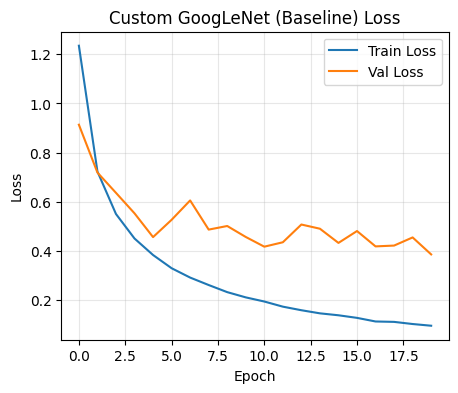

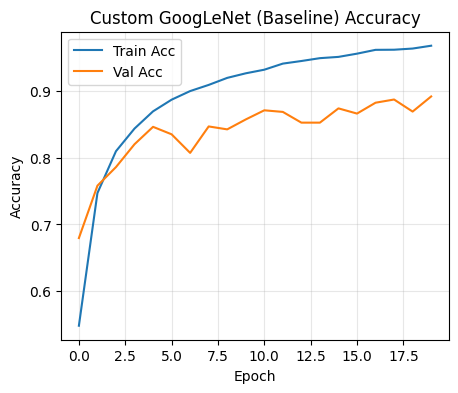

Test Accuracy: 89.21%


In [14]:
# Baseline (no aux)
gn_base = GoogLeNet(num_classes=10, use_aux=False).to(device)
gn_base, trL_gb, vaL_gb, trA_gb, vaA_gb = train_model(gn_base, trainloader, testloader, epochs=20, lr=0.01, aux_weight=0.0)

plot_curves(trA_gb, vaA_gb, trL_gb, vaL_gb, "Custom GoogLeNet (Baseline)")
gn_base_acc = test_accuracy(gn_base, testloader)


In [ ]:
plot_curves(trA_gb, vaA_gb, trL_gb, vaL_gb, "Custom GoogLeNet (Baseline)")
gn_base_acc = test_accuracy(gn_base, testloader)

In [31]:
# With auxiliary α=0.3
gn_aux = GoogLeNet(num_classes=10, use_aux=True).to(device)
gn_aux, trL_ga, vaL_ga, trA_ga, vaA_ga = train_model(gn_aux, trainloader, testloader, epochs=20, lr=0.01, aux_weight=0.3)


Epoch 1/20 | TrainAcc=0.557 | ValAcc=0.659 | TrainLoss=2.116| ValidationLoss=0.984
Epoch 2/20 | TrainAcc=0.739 | ValAcc=0.721 | TrainLoss=1.286| ValidationLoss=0.814
Epoch 3/20 | TrainAcc=0.807 | ValAcc=0.740 | TrainLoss=0.986| ValidationLoss=0.844
Epoch 4/20 | TrainAcc=0.837 | ValAcc=0.802 | TrainLoss=0.832| ValidationLoss=0.642
Epoch 5/20 | TrainAcc=0.864 | ValAcc=0.762 | TrainLoss=0.707| ValidationLoss=0.741
Epoch 6/20 | TrainAcc=0.879 | ValAcc=0.844 | TrainLoss=0.631| ValidationLoss=0.474
Epoch 7/20 | TrainAcc=0.894 | ValAcc=0.833 | TrainLoss=0.558| ValidationLoss=0.538
Epoch 8/20 | TrainAcc=0.903 | ValAcc=0.846 | TrainLoss=0.514| ValidationLoss=0.475
Epoch 9/20 | TrainAcc=0.914 | ValAcc=0.801 | TrainLoss=0.460| ValidationLoss=0.644
Epoch 10/20 | TrainAcc=0.922 | ValAcc=0.867 | TrainLoss=0.420| ValidationLoss=0.404
Epoch 11/20 | TrainAcc=0.928 | ValAcc=0.840 | TrainLoss=0.385| ValidationLoss=0.542
Epoch 12/20 | TrainAcc=0.935 | ValAcc=0.859 | TrainLoss=0.351| ValidationLoss=0.500
E

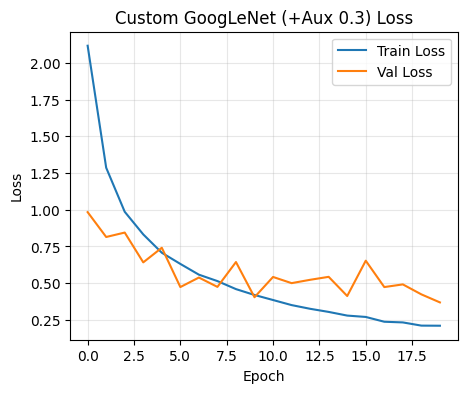

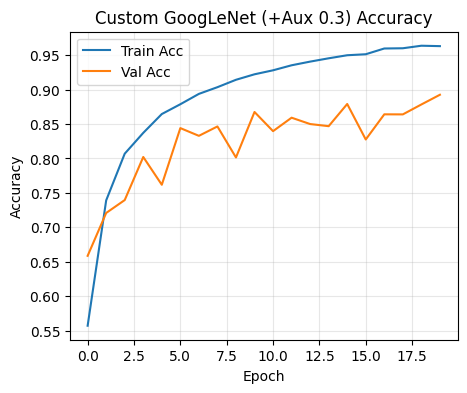

Test Accuracy: 89.24%


In [32]:
plot_curves(trA_ga, vaA_ga, trL_ga, vaL_ga, "Custom GoogLeNet (+Aux 0.3)")
gn_aux_acc = test_accuracy(gn_aux, testloader)

In [16]:
import os

def save_model(model, name="model", folder="saved_models"):
    os.makedirs(folder, exist_ok=True)
    path = os.path.join(folder, f"{name}.pth")
    torch.save(model.state_dict(), path)
    print(f"✅ Model saved to {path}")

def load_model(model_class, name="model", folder="saved_models", map_location=None):
    path = os.path.join(folder, f"{name}.pth")
    model = model_class()
    model.load_state_dict(torch.load(path, map_location=map_location or device))
    model.to(device)
    print(f"✅ Model loaded from {path}")
    return model

In [17]:
save_model(alexnet, "alexnet_cifar10")


✅ Model saved to saved_models/alexnet_cifar10.pth


In [33]:
save_model(gn_base, "googlenet_baseline")
save_model(gn_aux, "googlenet_aux03")


✅ Model saved to saved_models/googlenet_baseline.pth
✅ Model saved to saved_models/googlenet_aux03.pth


In [34]:
print(f"AlexNet (Custom) Test Accuracy     : {alex_acc:.4f}")
print(f"GoogLeNet (Baseline) Test Accuracy : {gn_base_acc:.4f}")
print(f"GoogLeNet (+Aux 0.3) Test Accuracy : {gn_aux_acc:.4f}")

AlexNet (Custom) Test Accuracy     : 0.7985
GoogLeNet (Baseline) Test Accuracy : 0.8921
GoogLeNet (+Aux 0.3) Test Accuracy : 0.8924


## Explaination
In general, auxiliary heads (α = 0.3) increase consistency, stability and final accuracy by giving previous layers more gradient signals and serving as gentle regularizers. GoogLeNet often performs better than AlexNet on CIFAR-10 because of its greater representational capacity, although AlexNet can still be a powerful basic baseline with appropriate augmentation.

In [18]:

import torch
import torch.nn as nn

class VGG16CIFAR10(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        # Block 1: 3x32x32 -> 64x32x32 -> 64x32x32 -> 64x16x16
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # Block 2: 64x16x16 -> 128x16x16 -> 128x16x16 -> 128x8x8
        self.block2 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # Block 3: 128x8x8 -> 256x8x8 -> 256x8x8 -> 256x8x8 -> 256x4x4
        self.block3 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # Block 4: 256x4x4 -> 512x4x4 -> 512x4x4 -> 512x4x4 -> 512x2x2
        self.block4 = nn.Sequential(
            nn.Conv2d(256, 512, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(512), nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(512), nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(512), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # Block 5: 512x2x2 -> 512x2x2 -> 512x2x2 -> 512x2x2 -> 512x1x1
        self.block5 = nn.Sequential(
            nn.Conv2d(512, 512, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(512), nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(512), nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(512), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # Classifier: 512x1x1 -> 512 -> 10
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.block5(x)
        x = self.classifier(x)
        return x

In [22]:
vgg = VGG16CIFAR10(num_classes=10).to(device)
vgg, trL_v, vaL_v, trA_v, vaA_v = train_model(
    vgg, trainloader, testloader,
    epochs=EPOCHS, lr=LEARNING_RATE, aux_weight=0.0
)

Epoch 1/20 | TrainAcc=0.453 | ValAcc=0.583 | TrainLoss=1.479| ValidationLoss=1.171
Epoch 2/20 | TrainAcc=0.652 | ValAcc=0.675 | TrainLoss=0.995| ValidationLoss=0.927
Epoch 3/20 | TrainAcc=0.731 | ValAcc=0.721 | TrainLoss=0.789| ValidationLoss=0.841
Epoch 4/20 | TrainAcc=0.772 | ValAcc=0.784 | TrainLoss=0.680| ValidationLoss=0.636
Epoch 5/20 | TrainAcc=0.803 | ValAcc=0.799 | TrainLoss=0.587| ValidationLoss=0.608
Epoch 6/20 | TrainAcc=0.823 | ValAcc=0.813 | TrainLoss=0.534| ValidationLoss=0.577
Epoch 7/20 | TrainAcc=0.837 | ValAcc=0.804 | TrainLoss=0.488| ValidationLoss=0.603
Epoch 8/20 | TrainAcc=0.853 | ValAcc=0.833 | TrainLoss=0.441| ValidationLoss=0.502
Epoch 9/20 | TrainAcc=0.860 | ValAcc=0.838 | TrainLoss=0.418| ValidationLoss=0.479
Epoch 10/20 | TrainAcc=0.870 | ValAcc=0.833 | TrainLoss=0.385| ValidationLoss=0.493
Epoch 11/20 | TrainAcc=0.879 | ValAcc=0.822 | TrainLoss=0.366| ValidationLoss=0.551
Epoch 12/20 | TrainAcc=0.886 | ValAcc=0.862 | TrainLoss=0.343| ValidationLoss=0.416
E

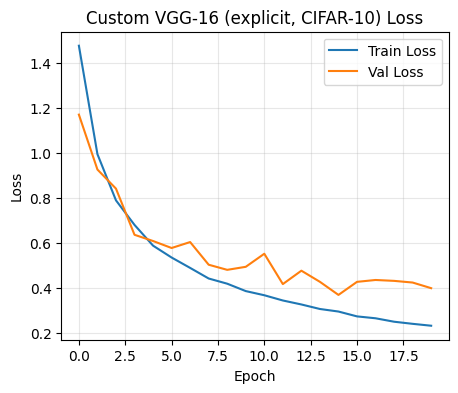

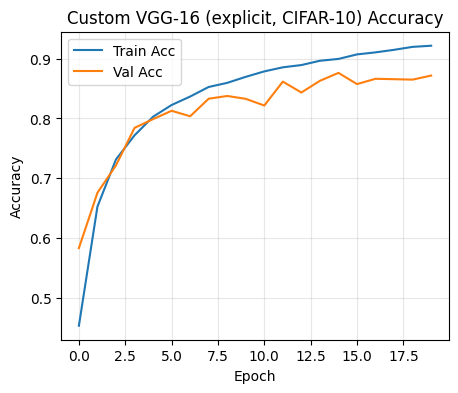

Test Accuracy: 87.19%
✅ Model saved to saved_models/vgg16_cifar10_custom_explicit.pth


In [23]:
plot_curves(trA_v, vaA_v, trL_v, vaL_v, "Custom VGG-16 (explicit, CIFAR-10)")
vgg_acc = test_accuracy(vgg, testloader)
save_model(vgg, "vgg16_cifar10_custom_explicit")


In [24]:
import torch
import torch.nn as nn

class InceptionB(nn.Module):
    
    def __init__(self, in_ch: int, n: int = 3,
                 c1: int = 64,          
                 c3red: int = 64, c3: int = 64, 
                 cdblred: int = 64, cdbl: int = 64,
                 cpool: int = 64): 
        super().__init__()
        
        self.b1 = nn.Sequential(
            nn.Conv2d(in_ch, c1, kernel_size=1, bias=False),
            nn.BatchNorm2d(c1), nn.ReLU(inplace=True)
        )
        
        self.b2 = nn.Sequential(
            nn.Conv2d(in_ch, c3red, kernel_size=1, bias=False),
            nn.BatchNorm2d(c3red), nn.ReLU(inplace=True),
            nn.Conv2d(c3red, c3red, kernel_size=(1, n), padding=(0, n//2), bias=False),
            nn.BatchNorm2d(c3red), nn.ReLU(inplace=True),
            nn.Conv2d(c3red, c3, kernel_size=(n, 1), padding=(n//2, 0), bias=False),
            nn.BatchNorm2d(c3), nn.ReLU(inplace=True)
        )
        
        self.b3 = nn.Sequential(
            nn.Conv2d(in_ch, cdblred, kernel_size=1, bias=False),
            nn.BatchNorm2d(cdblred), nn.ReLU(inplace=True),
            nn.Conv2d(cdblred, cdblred, kernel_size=(1, n), padding=(0, n//2), bias=False),
            nn.BatchNorm2d(cdblred), nn.ReLU(inplace=True),
            nn.Conv2d(cdblred, cdblred, kernel_size=(n, 1), padding=(n//2, 0), bias=False),
            nn.BatchNorm2d(cdblred), nn.ReLU(inplace=True),
            nn.Conv2d(cdblred, cdblred, kernel_size=(1, n), padding=(0, n//2), bias=False),
            nn.BatchNorm2d(cdblred), nn.ReLU(inplace=True),
            nn.Conv2d(cdblred, cdbl, kernel_size=(n, 1), padding=(n//2, 0), bias=False),
            nn.BatchNorm2d(cdbl), nn.ReLU(inplace=True)
        )
        
        self.b4 = nn.Sequential(
            nn.MaxPool2d(kernel_size=3, stride=1, padding=1),
            nn.Conv2d(in_ch, cpool, kernel_size=1, bias=False),
            nn.BatchNorm2d(cpool), nn.ReLU(inplace=True)
        )
        self.out_ch = c1 + c3 + cdbl + cpool
        assert self.out_ch == in_ch, 

    def forward(self, x):
        return torch.cat([self.b1(x), self.b2(x), self.b3(x), self.b4(x)], dim=1)

In [25]:
class InceptionBNet(nn.Module):
   
    def __init__(self, num_classes=10, n=3):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 192, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(192), nn.ReLU(inplace=True),
            nn.MaxPool2d(3, stride=2, padding=1),      # 32->16
            nn.Conv2d(192, 256, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(256), nn.ReLU(inplace=True),
        )
        # keep width 256 in all B blocks: choose branches that sum to 256
        def B(): return InceptionB(256, n=n, c1=64, c3red=64, c3=64, cdblred=32, cdbl=64, cpool=64)
        self.b1 = B()
        self.b2 = B()
        # downsample once between stacks for 16->8
        self.reduction = nn.MaxPool2d(3, stride=2, padding=1)  # 16->8
        self.b3 = B()
        self.b4 = B()
        self.b5 = B()
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d((1,1)),
            nn.Flatten(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.b1(x); x = self.b2(x)
        x = self.reduction(x)
        x = self.b3(x); x = self.b4(x); x = self.b5(x)
        x = self.head(x)
        return x

In [26]:

inceptB = InceptionBNet(num_classes=10, n=3).to(device)
inceptB, trL_ib, vaL_ib, trA_ib, vaA_ib = train_model(inceptB, trainloader, testloader, epochs=EPOCHS, lr=LEARNING_RATE, aux_weight=0.0)


Epoch 1/20 | TrainAcc=0.480 | ValAcc=0.558 | TrainLoss=1.425| ValidationLoss=1.301
Epoch 2/20 | TrainAcc=0.658 | ValAcc=0.665 | TrainLoss=0.964| ValidationLoss=0.960
Epoch 3/20 | TrainAcc=0.728 | ValAcc=0.718 | TrainLoss=0.782| ValidationLoss=0.833
Epoch 4/20 | TrainAcc=0.769 | ValAcc=0.764 | TrainLoss=0.663| ValidationLoss=0.691
Epoch 5/20 | TrainAcc=0.800 | ValAcc=0.794 | TrainLoss=0.580| ValidationLoss=0.612
Epoch 6/20 | TrainAcc=0.819 | ValAcc=0.785 | TrainLoss=0.524| ValidationLoss=0.656
Epoch 7/20 | TrainAcc=0.835 | ValAcc=0.823 | TrainLoss=0.477| ValidationLoss=0.522
Epoch 8/20 | TrainAcc=0.847 | ValAcc=0.821 | TrainLoss=0.444| ValidationLoss=0.538
Epoch 9/20 | TrainAcc=0.859 | ValAcc=0.803 | TrainLoss=0.415| ValidationLoss=0.593
Epoch 10/20 | TrainAcc=0.867 | ValAcc=0.827 | TrainLoss=0.385| ValidationLoss=0.504
Epoch 11/20 | TrainAcc=0.877 | ValAcc=0.825 | TrainLoss=0.361| ValidationLoss=0.556
Epoch 12/20 | TrainAcc=0.882 | ValAcc=0.831 | TrainLoss=0.342| ValidationLoss=0.539
E

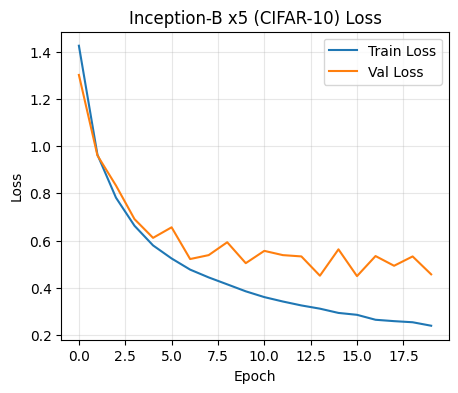

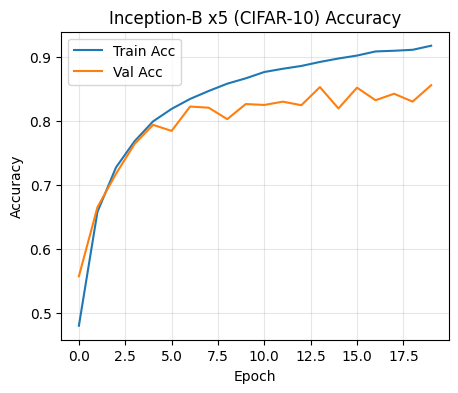

Test Accuracy: 85.63%
✅ Model saved to saved_models/inceptionB_x5_cifar10.pth


In [27]:
plot_curves(trA_ib, vaA_ib, trL_ib, vaL_ib, "Inception-B x5 (CIFAR-10)")
inceptB_acc = test_accuracy(inceptB, testloader)
save_model(inceptB, "inceptionB_x5_cifar10")

In [36]:

print("Final Comparison")
print(f"AlexNet (Custom) Test Accuracy     : {alex_acc:.4f}")
print(f"GoogLeNet (Baseline) Test Accuracy : {gn_base_acc:.4f}")
print(f"GoogLeNet (+Aux 0.3) Test Accuracy : {gn_aux_acc:.4f}")
print(f"VGG-16 (Custom) Test Accuracy      : {vgg_acc:.4f}")

print(f"Inception-B x5 (Custom) Test Acc   : {inceptB_acc:.4f}")

Final Comparison
AlexNet (Custom) Test Accuracy     : 0.7985
GoogLeNet (Baseline) Test Accuracy : 0.8921
GoogLeNet (+Aux 0.3) Test Accuracy : 0.8924
VGG-16 (Custom) Test Accuracy      : 0.8719
Inception-B x5 (Custom) Test Acc   : 0.8563
